
ETAPA 1 - CARREGAMENTO DOS DADOS

Número de amostras: 768
Número de atributos: 8

Nomes dos atributos:
['Compacidade_Relativa', 'Area_Superficie', 'Area_Paredes', 'Area_Telhado', 'Altura_Total', 'Orientacao', 'Area_Envidracada', 'Distribuicao_Area_Envidracada']

Variáveis-alvo:
['Carga_Aquecimento', 'Carga_Resfriamento']

Primeiros registros:
   Compacidade_Relativa  Area_Superficie  Area_Paredes  Area_Telhado  \
0                  0.98            514.5         294.0        110.25   
1                  0.98            514.5         294.0        110.25   
2                  0.98            514.5         294.0        110.25   
3                  0.98            514.5         294.0        110.25   
4                  0.90            563.5         318.5        122.50   

   Altura_Total  Orientacao  Area_Envidracada  Distribuicao_Area_Envidracada  \
0           7.0           2               0.0                              0   
1           7.0           3               0.0                

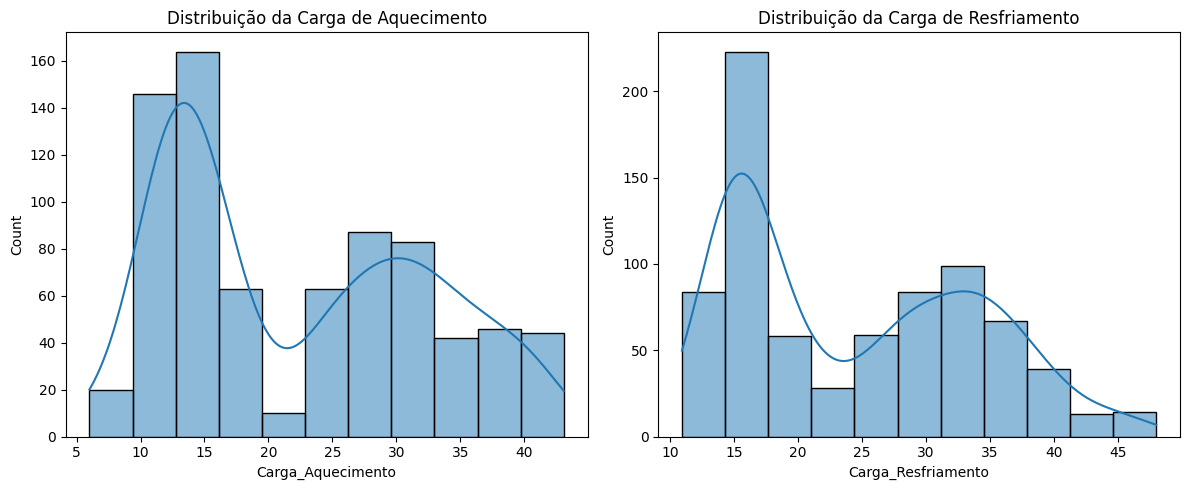


ETAPA 3 - ESTATÍSTICAS DESCRITIVAS

Resumo estatístico:
       Compacidade_Relativa  Area_Superficie  Area_Paredes  Area_Telhado  \
count            768.000000       768.000000    768.000000    768.000000   
mean               0.764167       671.708333    318.500000    176.604167   
std                0.105777        88.086116     43.626481     45.165950   
min                0.620000       514.500000    245.000000    110.250000   
25%                0.682500       606.375000    294.000000    140.875000   
50%                0.750000       673.750000    318.500000    183.750000   
75%                0.830000       741.125000    343.000000    220.500000   
max                0.980000       808.500000    416.500000    220.500000   

       Altura_Total  Orientacao  Area_Envidracada  \
count     768.00000  768.000000        768.000000   
mean        5.25000    3.500000          0.234375   
std         1.75114    1.118763          0.133221   
min         3.50000    2.000000          0.000

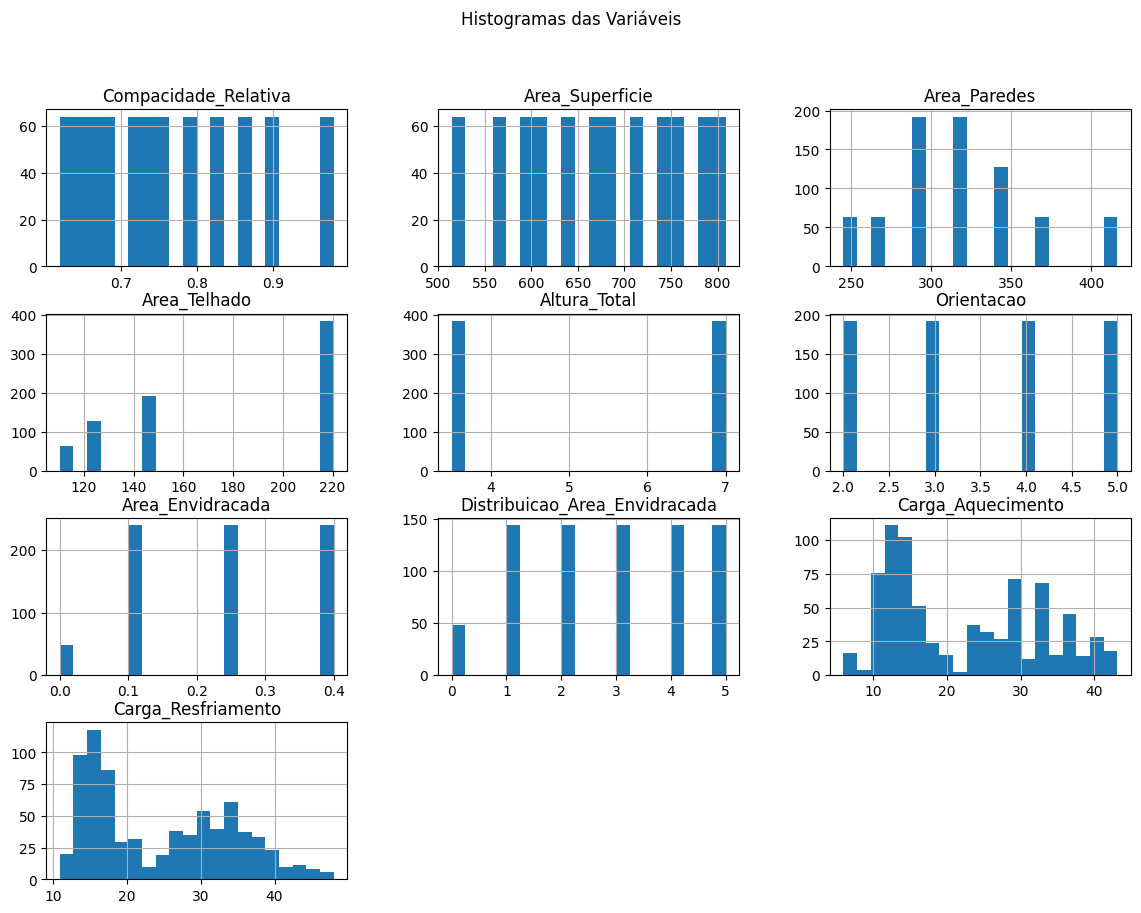

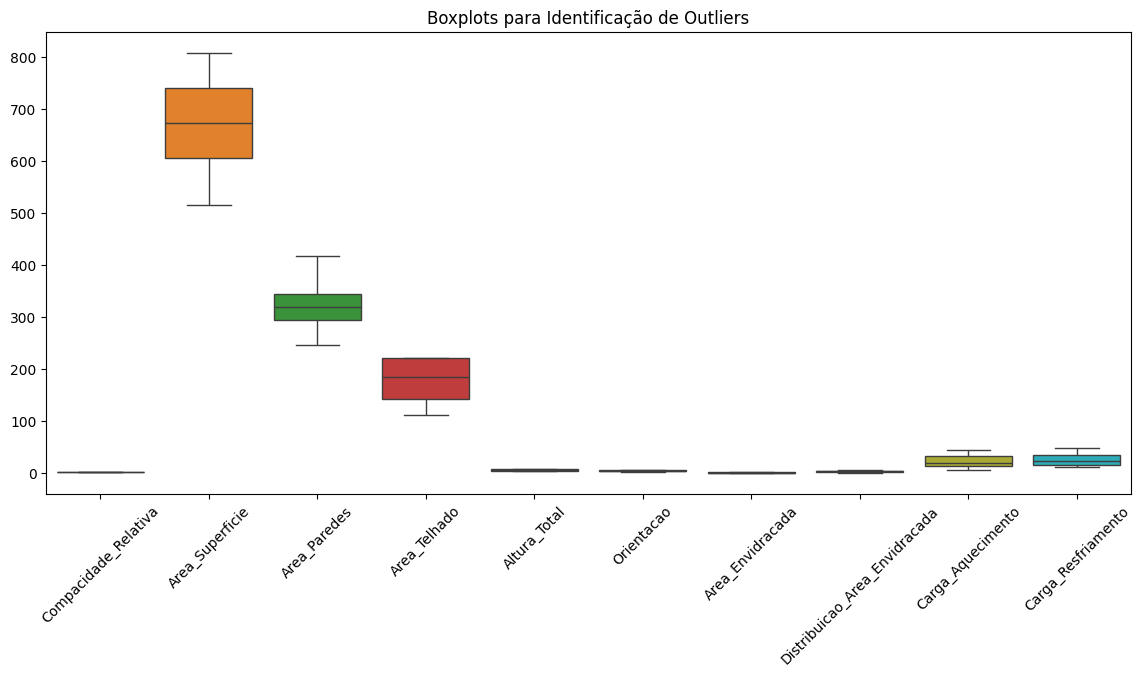

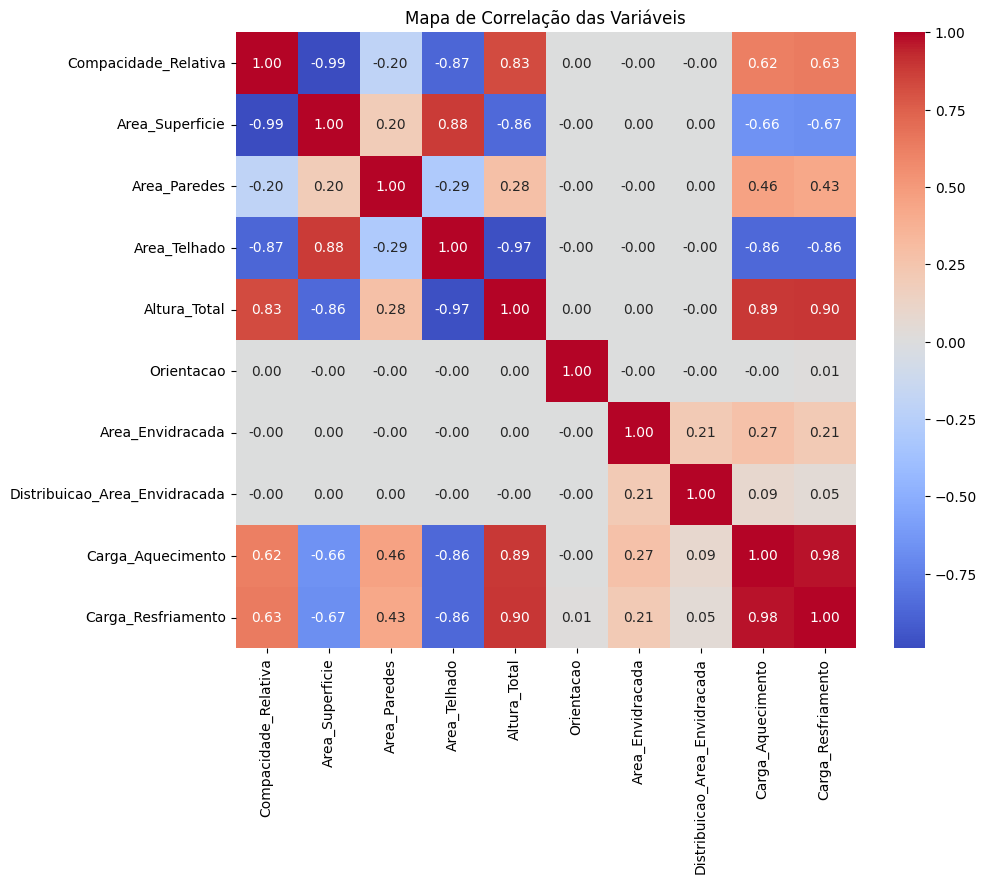

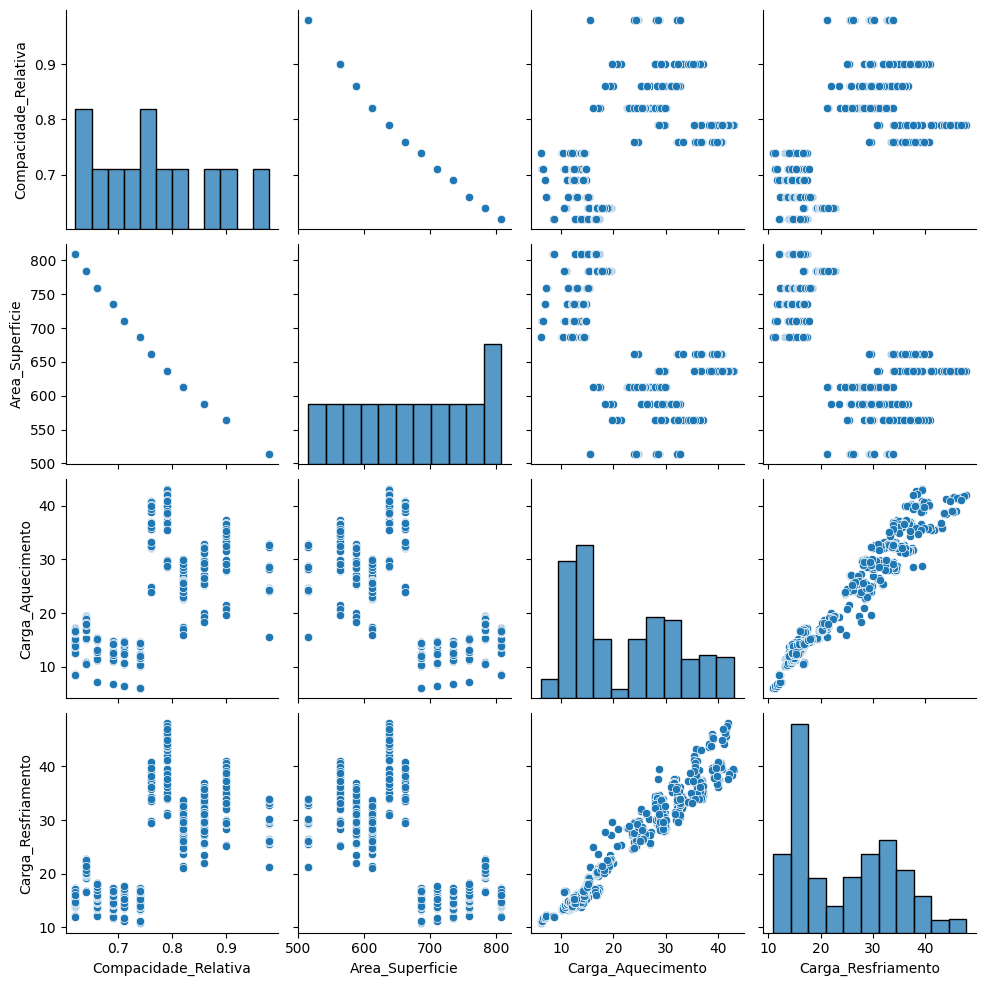


ETAPA 5 - PRÉ-PROCESSAMENTO

Pré-processamento concluído.

Justificativas:
- Não existem valores faltantes.
- Não existem atributos categóricos.
- Foi utilizada padronização com StandardScaler.
- A padronização reduz diferenças de escala entre atributos.

ETAPA 6 - TREINO E TESTE

Amostras de treino: 614
Amostras de teste: 154

ETAPA 7 - TREINAMENTO DOS MODELOS

Validação Cruzada (CV = 5)

Regressão Linear
Scores: [0.81488466 0.87808518 0.90837292 0.9104769  0.90201085]
Média: 0.8827661034996883

Floresta Aleatória
Scores: [0.87686332 0.97716104 0.98961894 0.98428992 0.97807895]
Média: 0.9612024350144128

ETAPA 8 - AVALIAÇÃO DOS MODELOS

===== Regressão Linear =====
MSE  : 9.5233
RMSE : 3.0860
MAE  : 2.1887
R²   : 0.9027

===== Ramdom Florest =====
MSE  : 1.6590
RMSE : 1.2880
MAE  : 0.7171
R²   : 0.9822

Tabela Comparativa:
             Modelo       MSE      RMSE       MAE        R2
0  Regressão Linear  9.523318  3.085987  2.188684  0.902705
1    Ramdom Florest  1.659017  1.288028  0.

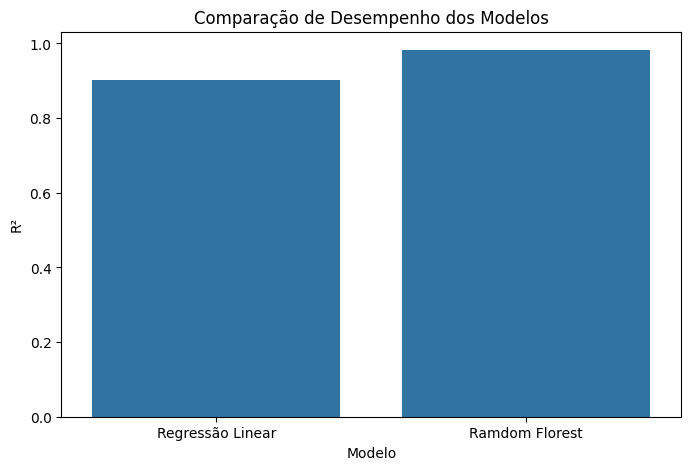


CONCLUSÃO

Melhor modelo encontrado: Ramdom Florest

O modelo foi escolhido com base no maior valor de R².
Quanto mais próximo de 1, melhor a capacidade de previsão.


In [2]:
# ==========================================================
# PROJETO DE MACHINE LEARNING
# PREVISÃO DE EFICIÊNCIA ENERGÉTICA DE EDIFÍCIOS
# ==========================================================

# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ==========================================================
# ETAPA 1 — CARREGAMENTO DOS DADOS
# ==========================================================

print("\n" + "="*60)
print("ETAPA 1 - CARREGAMENTO DOS DADOS")
print("="*60)

# Caminho do arquivo baixado do Kaggle
df = pd.read_excel("ENB2012_data.xlsx")

# Renomeando as colunas para português
df.columns = [
    "Compacidade_Relativa",
    "Area_Superficie",
    "Area_Paredes",
    "Area_Telhado",
    "Altura_Total",
    "Orientacao",
    "Area_Envidracada",
    "Distribuicao_Area_Envidracada",
    "Carga_Aquecimento",
    "Carga_Resfriamento"
]

print(f"\nNúmero de amostras: {df.shape[0]}")
print(f"Número de atributos: {df.shape[1]-2}")

print("\nNomes dos atributos:")
print(df.columns[:-2].tolist())

print("\nVariáveis-alvo:")
print(["Carga_Aquecimento", "Carga_Resfriamento"])

print("\nPrimeiros registros:")
print(df.head())

# ==========================================================
# ETAPA 2 — ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)
# ==========================================================

print("\n" + "="*60)
print("ETAPA 2 - ANÁLISE EXPLORATÓRIA")
print("="*60)

print("\nInformações gerais:")
print(df.info())

print("\nValores faltantes:")
print(df.isnull().sum())

# Distribuição das variáveis-alvo
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    df["Carga_Aquecimento"],
    kde=True,
    ax=ax[0]
)

ax[0].set_title("Distribuição da Carga de Aquecimento")

sns.histplot(
    df["Carga_Resfriamento"],
    kde=True,
    ax=ax[1]
)

ax[1].set_title("Distribuição da Carga de Resfriamento")

plt.tight_layout()
plt.show()

# ==========================================================
# ETAPA 3 — ESTATÍSTICAS DESCRITIVAS
# ==========================================================

print("\n" + "="*60)
print("ETAPA 3 - ESTATÍSTICAS DESCRITIVAS")
print("="*60)

print("\nResumo estatístico:")
print(df.describe())

estatisticas = pd.DataFrame({
    "Média": df.mean(),
    "Mediana": df.median(),
    "Desvio_Padrão": df.std(),
    "Mínimo": df.min(),
    "Máximo": df.max()
})

print("\nEstatísticas detalhadas:")
print(estatisticas)

# ==========================================================
# ETAPA 4 — VISUALIZAÇÕES GRÁFICAS
# ==========================================================

print("\n" + "="*60)
print("ETAPA 4 - VISUALIZAÇÕES")
print("="*60)

# Histogramas
df.hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Histogramas das Variáveis")
plt.show()

# Boxplots
plt.figure(figsize=(14, 6))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Boxplots para Identificação de Outliers")
plt.show()

# Heatmap de correlação
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de Correlação das Variáveis")
plt.show()

# Scatter plots
sns.pairplot(
    df[
        [
            "Compacidade_Relativa",
            "Area_Superficie",
            "Carga_Aquecimento",
            "Carga_Resfriamento"
        ]
    ]
)

plt.show()

# ==========================================================
# ETAPA 5 — PRÉ-PROCESSAMENTO
# ==========================================================

print("\n" + "="*60)
print("ETAPA 5 - PRÉ-PROCESSAMENTO")
print("="*60)

X = df.drop(
    columns=[
        "Carga_Aquecimento",
        "Carga_Resfriamento"
    ]
)

y = df[
    [
        "Carga_Aquecimento",
        "Carga_Resfriamento"
    ]
]

# Padronização dos atributos
escalonador = StandardScaler()

X_escalonado = escalonador.fit_transform(X)

print("\nPré-processamento concluído.")

print("\nJustificativas:")
print("- Não existem valores faltantes.")
print("- Não existem atributos categóricos.")
print("- Foi utilizada padronização com StandardScaler.")
print("- A padronização reduz diferenças de escala entre atributos.")

# ==========================================================
# ETAPA 6 — SEPARAÇÃO TREINO E TESTE
# ==========================================================

print("\n" + "="*60)
print("ETAPA 6 - TREINO E TESTE")
print("="*60)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_escalonado,
    y,
    test_size=0.20,
    random_state=42
)

print(f"\nAmostras de treino: {X_treino.shape[0]}")
print(f"Amostras de teste: {X_teste.shape[0]}")

# ==========================================================
# ETAPA 7 — APLICAÇÃO DOS ALGORITMOS
# ==========================================================

print("\n" + "="*60)
print("ETAPA 7 - TREINAMENTO DOS MODELOS")
print("="*60)

# ----------------------------------------------------------
# MODELO 1 - REGRESSÃO LINEAR
# ----------------------------------------------------------

modelo_regressao_linear = MultiOutputRegressor(
    LinearRegression()
)

modelo_regressao_linear.fit(
    X_treino,
    y_treino
)

predicoes_regressao_linear = (
    modelo_regressao_linear.predict(X_teste)
)

# ----------------------------------------------------------
# MODELO 2 - FLORESTA ALEATÓRIA
# ----------------------------------------------------------

modelo_floresta_aleatoria = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
)

modelo_floresta_aleatoria.fit(
    X_treino,
    y_treino
)

predicoes_floresta_aleatoria = (
    modelo_floresta_aleatoria.predict(X_teste)
)

# ----------------------------------------------------------
# VALIDAÇÃO CRUZADA
# ----------------------------------------------------------

print("\nValidação Cruzada (CV = 5)")

cv_regressao_linear = cross_val_score(
    modelo_regressao_linear,
    X_escalonado,
    y,
    cv=5,
    scoring="r2"
)

cv_floresta_aleatoria = cross_val_score(
    modelo_floresta_aleatoria,
    X_escalonado,
    y,
    cv=5,
    scoring="r2"
)

print("\nRegressão Linear")
print("Scores:", cv_regressao_linear)
print("Média:", cv_regressao_linear.mean())

print("\nFloresta Aleatória")
print("Scores:", cv_floresta_aleatoria)
print("Média:", cv_floresta_aleatoria.mean())

# ==========================================================
# ETAPA 8 — AVALIAÇÃO DOS MODELOS
# ==========================================================

print("\n" + "="*60)
print("ETAPA 8 - AVALIAÇÃO DOS MODELOS")
print("="*60)

def avaliar_modelo(nome, valores_reais, previsoes):

    mse = mean_squared_error(
        valores_reais,
        previsoes
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        valores_reais,
        previsoes
    )

    r2 = r2_score(
        valores_reais,
        previsoes
    )

    print(f"\n===== {nome} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Modelo": nome,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

resultado_regressao_linear = avaliar_modelo(
    "Regressão Linear",
    y_teste,
    predicoes_regressao_linear
)

resultado_floresta_aleatoria = avaliar_modelo(
    "Ramdom Florest",
    y_teste,
    predicoes_floresta_aleatoria
)

# ==========================================================
# COMPARAÇÃO DOS MODELOS
# ==========================================================

comparacao = pd.DataFrame([
    resultado_regressao_linear,
    resultado_floresta_aleatoria
])

print("\nTabela Comparativa:")
print(comparacao)

# ==========================================================
# GRÁFICO COMPARATIVO
# ==========================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparacao,
    x="Modelo",
    y="R2"
)

plt.title("Comparação de Desempenho dos Modelos")
plt.ylabel("R²")
plt.show()

# ==========================================================
# CONCLUSÃO
# ==========================================================

melhor_modelo = comparacao.loc[
    comparacao["R2"].idxmax(),
    "Modelo"
]

print("\n" + "="*60)
print("CONCLUSÃO")
print("="*60)

print(f"\nMelhor modelo encontrado: {melhor_modelo}")

print("\nO modelo foi escolhido com base no maior valor de R².")
print("Quanto mais próximo de 1, melhor a capacidade de previsão.")